In [2]:
library(ggplot2)
library(tidyverse)
library(gridExtra)
library(GGally)
library(plotly)
library(corrplot)
library(reshape2)
library(FactoMineR) 
library(factoextra)
library(glmnet) 
library(ggfortify)
library(pROC)
library(ROCR)
library(GGally)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachement du package : 'gridExtra'


L'objet suivant est masqué depuis 'package:dplyr':

    combine



Attachement du package : 'plotly'


L'objet suivant est masqué depuis 'package:ggplot2':

    last_plot


L'objet suivant est masqué depuis 'package:stats':

    filter


L'objet suivant est masqué depuis 'package:graphics':

    layout


corrplot 0.95 loa

In [3]:
data<-read.csv("new_games.csv",header = TRUE)

In [5]:
summary(data)

     AppID             Name           Release.date       Estimated.owners  
 Min.   :     10   Length:122611      Length:122611      Length:122611     
 1st Qu.:1063175   Class :character   Class :character   Class :character  
 Median :1907380   Mode  :character   Mode  :character   Mode  :character  
 Mean   :1985386                                                           
 3rd Qu.:2869560                                                           
 Max.   :4264350                                                           
                                                                           
    Peak.CCU          Required.age         Price             Discount     
 Min.   :0.000e+00   Min.   : 0.0000   Min.   :   0.000   Min.   :  0.00  
 1st Qu.:0.000e+00   1st Qu.: 0.0000   1st Qu.:   0.550   1st Qu.:  0.00  
 Median :0.000e+00   Median : 0.0000   Median :   2.240   Median :  0.00  
 Mean   :5.459e+01   Mean   : 0.1676   Mean   :   4.765   Mean   : 18.35  
 3rd Qu.:0.000e+0

# Suppresion de variables inutiles à l'exploration des données

Il me semble que les variables ci-dessous sont plutôt des variables qualitatives donc je les ai converti.

In [6]:

data[,"Estimated.owners"]=as.factor(data[,"Estimated.owners"])
data[,"Required.age"]=as.factor(data[,"Required.age"])
data[,"Windows"]=as.factor(data[,"Windows"])
data[,"Mac"]=as.factor(data[,"Mac"])
data[,"Linux"]=as.factor(data[,"Linux"])


summary(data)

       

     AppID             Name           Release.date      
 Min.   :     10   Length:122611      Length:122611     
 1st Qu.:1063175   Class :character   Class :character  
 Median :1907380   Mode  :character   Mode  :character  
 Mean   :1985386                                        
 3rd Qu.:2869560                                        
 Max.   :4264350                                        
                                                        
        Estimated.owners    Peak.CCU          Required.age   
 0 - 20000      :75404   Min.   :0.000e+00   0      :121339  
 0 - 0          :21641   1st Qu.:0.000e+00   17     :   828  
 20000 - 50000  :11396   Median :0.000e+00   13     :   175  
 50000 - 100000 : 5355   Mean   :5.459e+01   18     :   164  
 100000 - 200000: 3454   3rd Qu.:0.000e+00   16     :    32  
 200000 - 500000: 2853   Max.   :1.014e+06   10     :    26  
 (Other)        : 2508                       (Other):    47  
     Price             Discount        DLC.count

J'ai choisi de supprimer plusieurs variable qui à mon avis ne seraient pas pertinente lors de l'analyse de certaine donnée. J'ai aussi supprimé la variable Movies car elle ne contennait que des NA.

In [12]:
data1 <- data %>% select(-c(AppID, About.the.game, Reviews,Movies,Header.image,Support.email,Support.url,Notes,Metacritic.url))

In [13]:
summary(data1)

     Name           Release.date              Estimated.owners
 Length:122611      Length:122611      0 - 20000      :75404  
 Class :character   Class :character   0 - 0          :21641  
 Mode  :character   Mode  :character   20000 - 50000  :11396  
                                       50000 - 100000 : 5355  
                                       100000 - 200000: 3454  
                                       200000 - 500000: 2853  
                                       (Other)        : 2508  
    Peak.CCU          Required.age        Price             Discount     
 Min.   :0.000e+00   0      :121339   Min.   :   0.000   Min.   :  0.00  
 1st Qu.:0.000e+00   17     :   828   1st Qu.:   0.550   1st Qu.:  0.00  
 Median :0.000e+00   13     :   175   Median :   2.240   Median :  0.00  
 Mean   :5.459e+01   18     :   164   Mean   :   4.765   Mean   : 18.35  
 3rd Qu.:0.000e+00   16     :    32   3rd Qu.:   5.240   3rd Qu.: 40.00  
 Max.   :1.014e+06   10     :    26   Max.   : 999.9

### Etude sur la variable supported.language

In [14]:
head(data1[,"Supported.languages"])

[1] "[]"                                                                                                                    
[2] "['English']"                                                                                                           
[3] "['English', 'French', 'German', 'Russian']"                                                                            
[4] "['Korean']"                                                                                                            
[5] "['English']"                                                                                                           
[6] "['English', 'French', 'Italian', 'German', 'Spanish - Spain', 'Polish', 'Portuguese - Portugal', 'Russian', 'Turkish']"

Plutôt que de garder la variable supported.languages qui ne contient que des chaines de caractère. On peut plutôt étudier le nombre de jeu supporté par chaque langue (première cellule) ou par jeux le nombre de langue supporté et esc ce que ça à une influence sur la note du jeu ou autre chose (deuxième cellule).

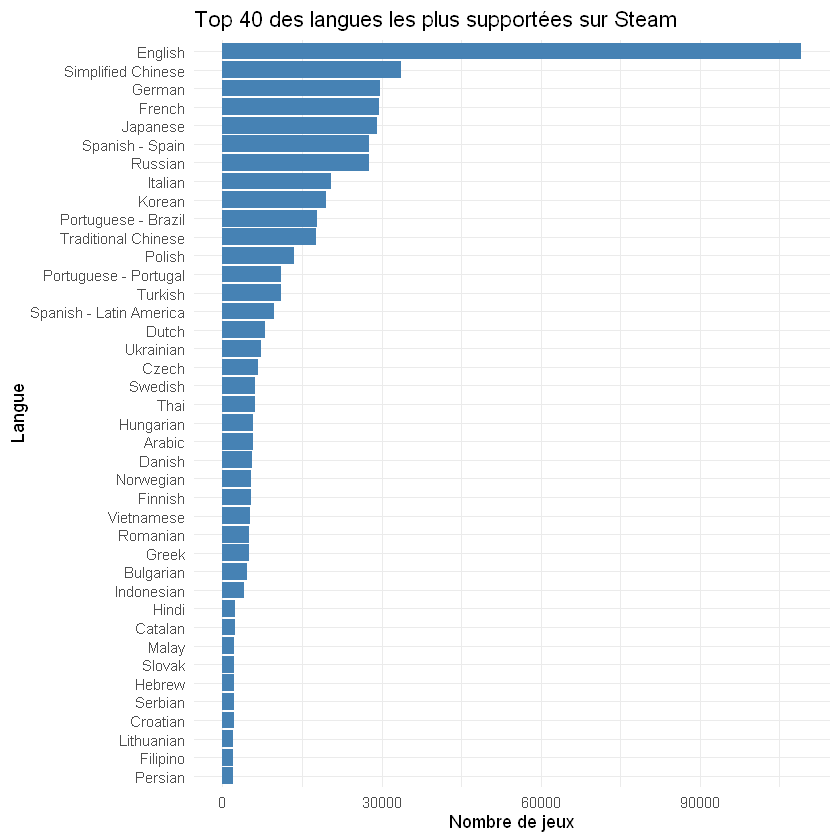

In [36]:
stats_langues <- data1 %>%
  # 1. On nettoie les symboles parasites [ ] ' "
  mutate(clean_txt = str_remove_all(Supported.languages, "\\[|\\]|'|\"")) %>%
  # 2. On "éclate" les listes : si un jeu a 3 langues, ça crée 3 lignes
  separate_rows(clean_txt, sep = ",\\s*") %>%
  # 3. On compte combien de fois chaque langue apparaît
  count(clean_txt, sort = TRUE) %>%
  # 4. On garde les 50 premières (en enlevant les vides)
  filter(clean_txt != "" & !is.na(clean_txt)) %>%
  head(40)


ggplot(stats_langues, aes(x = reorder(clean_txt, n), y = n)) +
  geom_col(fill = "steelblue") +
  coord_flip() + # Pour mettre les noms à l'horizontale 
  labs(
    title = "Top 40 des langues les plus supportées sur Steam",
    x = "Langue",
    y = "Nombre de jeux"
  ) +
  theme_minimal()

In [33]:
data1 <- data1 %>%
  mutate(nb_language_supported = str_count(Supported.languages, ",") + 1)
head(data1$nb_language_supported)

[1] 1 1 4 1 1 9

### Etude des variables developers et publishers

Je propose de faire de même pour les variables developers et publishers: c'est à dire de regarder si la note du jeu a un lien avec sont studio de développement et son publieur. j'ai converti les chaines de caractères en minuscule et envelevé les points car dans un premier temps j'ai vu que certains chaine de caractère étaient la même mais juste en majuscule .

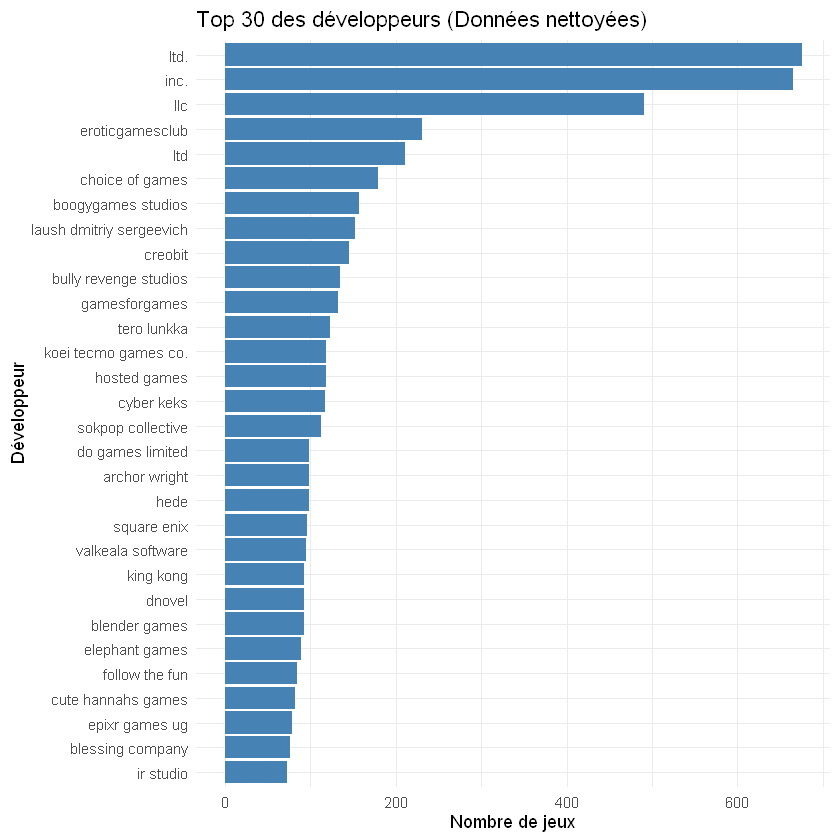

In [48]:
stat_developers <- data1 %>%
  # 1. On nettoie les symboles de liste
  mutate(clean_dev = str_remove_all(Developers, "\\[|\\]|'|\"\\.")) %>%
  # 2. On sépare les lignes (s'il y a plusieurs dev)
  separate_rows(clean_dev, sep = ",\\s*") %>%
  # 3. STANDARDISATION :
  mutate(
    clean_dev = str_to_lower(clean_dev),        # Tout en minuscules (ltd = LTD)
    clean_dev = str_trim(clean_dev)             # Enlever les espaces au début/fin
  ) %>%
  # 4. On compte
  count(clean_dev, sort = TRUE) %>%
  filter(clean_dev != "" & !is.na(clean_dev)) %>%
  head(30)


ggplot(stat_developers, aes(x = reorder(clean_dev, n), y = n)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Top 30 des développeurs (Données nettoyées)",
    x = "Développeur",
    y = "Nombre de jeux"
  ) +
  theme_minimal()



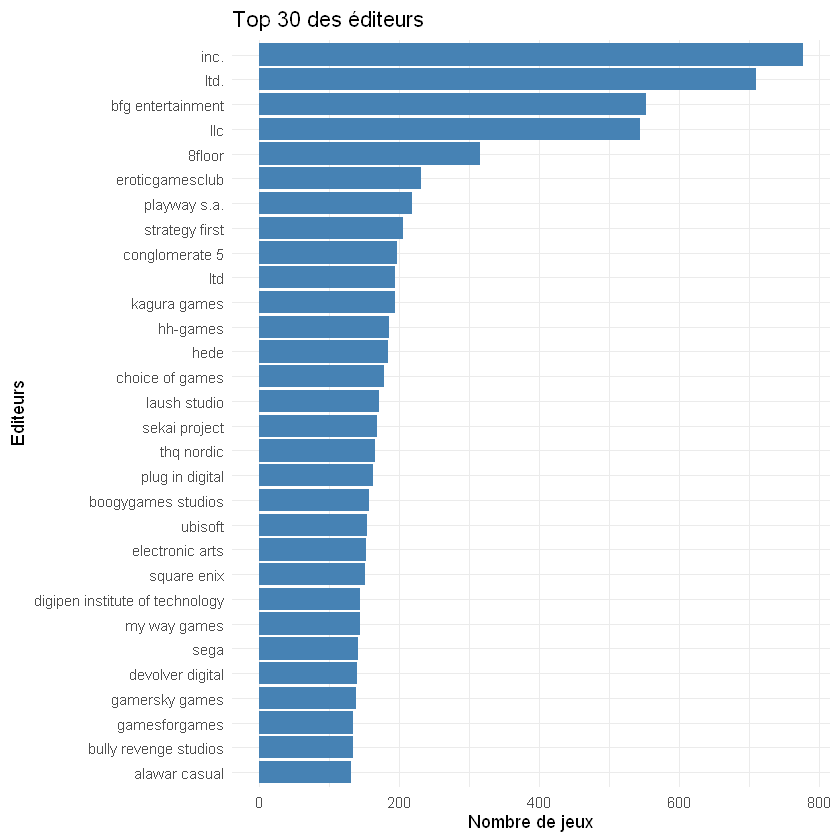

In [49]:
stat_publisher <- data1 %>%
  # 1. On nettoie les symboles de liste
  mutate(clean_publ = str_remove_all(Publishers, "\\[|\\]|'|\"\\.")) %>%
  # 2. On sépare les lignes (s'il y a plusieurs dev)
  separate_rows(clean_publ, sep = ",\\s*") %>%
  # 3. STANDARDISATION :
  mutate(
    clean_publ = str_to_lower(clean_publ),        # Tout en minuscules (ltd = LTD)
    clean_publ = str_trim(clean_publ)             # Enlever les espaces au début/fin
  ) %>%
  # 4. On compte
  count(clean_publ, sort = TRUE) %>%
  filter(clean_publ != "" & !is.na(clean_publ)) %>%
  head(30)


ggplot(stat_publisher, aes(x = reorder(clean_publ, n), y = n)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Top 30 des éditeurs ",
    x = "Editeurs",
    y = "Nombre de jeux"
  ) +
  theme_minimal()


### Etude variable release.date

A voir  comment les traiter: en variable qualitative ou autre .

In [50]:
data1$Release.date

[1] "Aug 1, 2023"  "Jul 29, 2016" "May 6, 2019"  "Oct 31, 2024"
    [5] "Apr 24, 2025" "Apr 5, 2023"  "Apr 8, 2025"  "Feb 1, 2018" 
    [9] "May 7, 2021"  "Dec 13, 2021" "Mar 25, 2022" "Sep 25, 2019"
   [13] "Sep 5, 2019"  "Apr 5, 2023"  "Apr 19, 2024" "Apr 29, 2020"
   [17] "Aug 10, 2023" "Oct 23, 2014" "Jan 9, 2023"  "Jul 28, 2023"
   [21] "Jan 24, 2025" "Oct 21, 2021" "Jun 1, 2018"  "Feb 14, 2024"
   [25] "Mar 8, 2023"  "Oct 4, 2023"  "Nov 16, 2018" "Jul 26, 2017"
   [29] "Dec 4, 2024"  "Jan 16, 2023" "Jan 26, 2022" "Jul 8, 2016" 
   [33] "Dec 13, 2024" "Nov 18, 2023" "May 5, 2015"  "Dec 20, 2020"
   [37] "Nov 11, 2022" "Jul 31, 2024" "Feb 14, 2024" "Jan 2, 2024" 
   [41] "Nov 28, 2019" "May 3, 2018"  "Sep 29, 2016" "May 29, 2025"
   [45] "Jul 31, 2025" "Aug 10, 2023" "Feb 21, 2024" "Jul 9, 2025" 
   [49] "Jan 7, 2022"  "Apr 8, 2025"  "Jan 1, 2025"  "Mar 20, 2024"
   [53] "Oct 21, 2024" "Dec 20, 2017" "Jun 11, 2020" "Jul 15, 2021"
   [57] "Feb 6, 2025"  "Feb 16, 2023" "Jan 28, 2020" "Mar 4, 2024" 
   [61] "Nov 16, 2020" "Jul 13, 2025" "Jun 7, 2023"  "Jun 17, 2025"
   [65] "Oct 27, 2021" "Feb 13, 2019" "Feb 8, 2018"  "Sep 14, 2018"
   [69] "Aug 6, 2020"  "Jun 4, 2015"  "Apr 29, 2024" "Feb 26, 2024"
   [73] "May 22, 2024" "Jan 3, 2023"  "Aug 21, 2025" "Feb 9, 2025" 
   [77] "Aug 31, 2020" "Jan 20, 2016" "Oct 17, 2025" "Sep 30, 2025"
   [81] "Jul 18, 2018" "Aug 13, 2021" "Jan 26, 2022" "Apr 9, 2025" 
   [85] "Sep 27, 2024" "Jun 18, 2021" "Dec 4, 2024"  "Jan 18, 2021"
   [89] "Mar 26, 2021" "Jun 24, 2025" "Jun 25, 2018" "Oct 13, 2020"
   [93] "May 8, 2021"  "Jul 11, 2025" "Oct 26, 2016" "Sep 24, 2019"
   [97] "Jun 3, 2022"  "Jan 17, 2024" "Feb 23, 2024" "Jun 8, 2025" 
  [101] "Oct 7, 2015"  "Mar 5, 2019"  "Apr 19, 2025" "Sep 16, 2014"
  [105] "Jan 8, 2025"  "Oct 29, 2013" "Apr 15, 2025" "Oct 25, 2022"
  [109] "Sep 29, 2023" "Dec 27, 2024" "Jul 17, 2020" "Sep 6, 2018" 
  [113] "Mar 11, 2019" "Mar 28, 2025" "Sep 8, 2025"  "Feb 27, 2019"
  [117] "Sep 24, 2025" "Feb 19, 2021" "Feb 25, 2021" "Jul 25, 2018"
  [121] "Oct 16, 2023" "Dec 8, 2019"  "Jan 27, 2020" "Oct 24, 2024"
  [125] "Feb 24, 2023" "Feb 28, 2017" "Nov 5, 2021"  "Dec 28, 2024"
  [129] "Apr 30, 2025" "Mar 19, 2024" "Feb 20, 2025" "Aug 14, 2023"
  [133] "Jan 10, 2025" "Oct 25, 2018" "Feb 5, 2023"  "Aug 9, 2025" 
  [137] "Oct 11, 2024" "Sep 10, 2021" "Dec 15, 2023" "Aug 4, 2023" 
  [141] "Mar 5, 2024"  "Mar 21, 2024" "Nov 19, 2018" "Nov 22, 2016"
  [145] "Jul 25, 2025" "Mar 22, 2019" "Dec 31, 2024" "Dec 18, 2015"
  [149] "Jun 25, 2018" "Nov 22, 2019" "Sep 22, 2016" "Jul 2, 2022" 
  [153] "Oct 4, 2020"  "Feb 29, 2024" "Oct 10, 2009" "Oct 8, 2021" 
  [157] "Jan 14, 2022" "Apr 17, 2020" "Oct 5, 2017"  "Sep 15, 2021"
  [161] "Jan 30, 2025" "Oct 7, 2019"  "Jan 5, 2021"  "Dec 19, 2024"
  [165] "Apr 3, 2023"  "Jan 8, 2025"  "Dec 9, 2024"  "Aug 6, 2025" 
  [169] "Jul 24, 2024" "Sep 14, 2025" "Jan 2, 2025"  "Nov 7, 2025" 
  [173] "Sep 21, 2023" "Feb 29, 2024" "Jun 8, 2024"  "Jan 5, 2023" 
  [177] "Feb 9, 2022"  "Mar 30, 2024" "Oct 5, 2022"  "Oct 11, 2025"
  [181] "Jun 5, 2014"  "Oct 13, 2023" "Jul 15, 2019" "Mar 24, 2023"
  [185] "Mar 4, 2025"  "Dec 17, 2016" "Sep 4, 2024"  "Jul 18, 2025"
  [189] "Dec 15, 2025" "Jan 14, 2018" "Aug 26, 2025" "Oct 21, 2025"
  [193] "Jun 11, 2020" "Oct 3, 2023"  "Nov 29, 2020" "Nov 14, 2024"
  [197] "Oct 31, 2023" "Nov 10, 2021" "Dec 1, 2023"  "May 29, 2024"
  [201] "Apr 11, 2025" "Nov 1, 2019"  "Feb 5, 2025"  "Sep 11, 2024"
  [205] "May 24, 2021" "Dec 19, 2024" "May 8, 2025"  "Feb 6, 2018" 
  [209] "Aug 24, 2025" "Aug 1, 2023"  "Oct 1, 2025"  "Oct 8, 2020" 
  [213] "Aug 20, 2020" "Jan 19, 2019" "Apr 14, 2017" "Apr 26, 2019"
  [217] "May 29, 2024" "Jan 22, 2016" "Nov 21, 2020" "Dec 5, 2017" 
  [221] "Oct 25, 2021" "May 16, 2018" "Jan 27, 2021" "Jul 30, 2025"
  [225] "Apr 6, 2018"  "Aug 31, 2023" "Sep 1, 2019"  "Jan 30, 2025"
  [229] "May 16, 2024" "Mar 9, 2018"  "Nov 20, 2013" "Jun 1, 2022" 
  [233] "Aug 18, 2022" "Nov 28, 2025" "Mar 12, 2023" "Feb 15

### Etude required.age

In [51]:
data1$Required.age

[1] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
   [25] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
   [49] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  17 0  0  0  0 
   [73] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
   [97] 0  0  0  0  0  0  0  0  0  17 0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [121] 0  18 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [145] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [169] 0  0  0  0  17 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [193] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [217] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [241] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  17 0  0 
  [265] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [289] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  17
  [313] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [337] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  13 0  0  0  0  0  0  0  0  0 
  [361] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [385] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [409] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  17 0  0  0  0  0  0  0  0  0 
  [433] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [457] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [481] 0  0  0  0  0  0  0  0  0  0  17 0  0  0  0  0  0  0  0  0  0  0  0  0 
  [505] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [529] 0  0  0  0  0  0  0  17 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [553] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [577] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [601] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [625] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [649] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [673] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [697] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [721] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [745] 0  0  0  0  0  0  0  0  0  0  0  0  0  17 0  0  0  0  0  0  0  0  0  0 
  [769] 0  0  0  0  0  0  0  0  0  0  0  17 0  0  0  0  0  0  0  0  0  0  0  0 
  [793] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [817] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [841] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [865] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [889] 17 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  17 0  0  0 
  [913] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
  [937] 0  0  0  0  0  0  0  0  0  0  17 0  0  0  0  0  0  18 0  0  0  0  0  0 
  [961] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  17 0  0  0  0 
  [985] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
 [1009] 0  17 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
 [1033] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
 [1057] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
 [1081] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
 [1105] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
 [1129] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
 [1153] 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
 [1177] 12 0  0  17 17 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
 [12

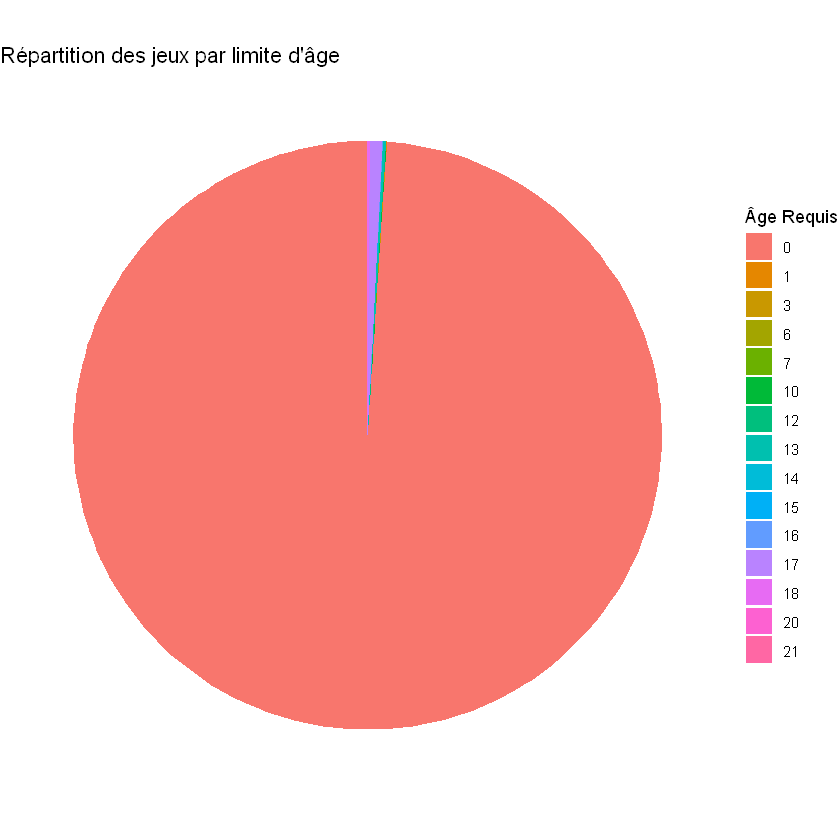

In [60]:
ggplot(data1, aes(x = factor(1),fill = Required.age))+ geom_bar(width = 1) +
  coord_polar("y") +
  theme_void() +
  labs(
    title = "Répartition des jeux par limite d'âge",
    fill = "Âge Requis"
  )

On remarque que les jeux qui n'ont pas de limites sont en grande majorité qui rends la lecture du pie chart compliquée. Il faudrait enlevé cette modalité pour réaliser la stat descriptive.